# Preprocessing UAV-Human 5 Classes — YOLO Detection → YOLO26 Pose

Pipeline:

**UAV-Human RGB video → YOLOv8 person detection → target tracking → bbox smoothing/recovery → crop + padding → YOLO26s-Pose → validasi COCO-17 → sequence 90 frame**

Kelas yang digunakan:

- `A008_applaud`
- `A019_wave_hands`
- `A042_punch_with_fists`
- `A046_squat`
- `A059_step_on_the_spot_walk`

Metadata `subject_ids.npy` disimpan dari kode `Pxxx` pada nama file agar training dapat memakai split berbasis subjek.


## 1. Import Library

In [1]:
import os, sys, json, time, shutil, subprocess, re
from pathlib import Path
from collections import deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Install dan Import Ultralytics

In [2]:
import torch
from functools import partial

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U', 'ultralytics'], check=True)
from ultralytics import YOLO
import ultralytics

torch.load = partial(torch.load, weights_only=False)
print('Ultralytics versi:', ultralytics.__version__)
print('CUDA tersedia    :', torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics versi: 8.4.96
CUDA tersedia    : True


## 3. Konfigurasi

In [3]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/wafabila/"
    "uav-human-5-clases/"
    "uav_human_subset_5_easy_classes"
)

CLASS_FOLDERS = {
    "A008_applaud": "applaud",
    "A019_wave_hands": "wave_hands",
    "A042_punch_with_fists": "punch_with_fists",
    "A046_squat": "squat",
    "A059_step_on_the_spot_walk": "step_on_the_spot_walk",
}

ACTIVITY_CLASSES = list(CLASS_FOLDERS.values())

VIDEO_EXTENSIONS = [
    "mp4",
    "avi",
    "mov",
    "mkv",
    "MP4",
    "AVI",
    "MOV",
    "MKV",
]

# Model deteksi orang
DETECTOR_MODEL_NAME = "yolov8s.pt"
DETECTOR_CONF = 0.25
DETECTOR_IMGSZ = 640

# Model pose
POSE_MODEL_NAME = "yolo26s-pose.pt"
POSE_CONF = 0.10
POSE_IMGSZ = 640
POSE_IOU = 0.50
POSE_MAX_DET = 5

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# Tracking bounding box
TRACK_MIN_IOU = 0.05
TRACK_MAX_CENTER_DISTANCE = 0.20
TRACK_IOU_WEIGHT = 0.65
TRACK_CENTER_WEIGHT = 0.35

BBOX_SMOOTH_WINDOW = 5
MAX_MISSING_BOX = 5

# Padding crop
YOLO_PAD_X = 0.45
YOLO_PAD_Y = 0.45

# Sliding window
SEQUENCE_LENGTH = 90
SEQUENCE_STEP = 30
MAX_MISSING_RATIO = 0.30

# COCO-17: x, y, confidence
NUM_KEYPOINT = 17
NUM_FEATURE_PER_KEYPOINT = 3
FEATURE_DIM = NUM_KEYPOINT * NUM_FEATURE_PER_KEYPOINT

VIDEO_FPS_DEFAULT = 25

# Validasi skeleton
KEYPOINT_CONF_THRESHOLD = 0.25
MIN_VALID_KEYPOINTS = 8
MIN_CORE_KEYPOINTS = 4

CORE_KEYPOINT_INDEX = [
    5, 6,
    11, 12,
    13, 14,
    15, 16,
]

KEYPOINT_MARGIN_RATIO = 0.10
KEYPOINT_MIN_SPAN_RATIO = 0.015
KEYPOINT_MAX_SPAN_RATIO = 1.50

# False = proses semua 840 video
# True  = hanya proses beberapa video untuk pengecekan cepat
DEBUG_MODE = False
DEBUG_MAX_VIDEO_PER_CLASS = 3

# Agar proses full tidak terlalu berat, hanya 1 overlay per kelas
OVERLAY_VIDEO_SAMPLE_PER_CLASS = 1

OUTPUT_DIR = (
    Path("/kaggle/working/preprocessed_final")
    / "uav_human_5_classes"
    / "h4_yolo_detection_yolo26_pose_seq90"
)

OVERLAY_DIR = OUTPUT_DIR / "overlay_video"
DEBUG_FRAME_DIR = OVERLAY_DIR / "debug_frames"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostic_images"

for folder in [
    OUTPUT_DIR,
    OVERLAY_DIR,
    DEBUG_FRAME_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("=" * 76)
print("KONFIGURASI PREPROCESSING UAV-HUMAN 5 KELAS")
print("=" * 76)
print("Dataset :", DATASET_ROOT)
print("Classes :", ACTIVITY_CLASSES)
print("Device  :", DEVICE)
print("Debug   :", DEBUG_MODE)
print("Output  :", OUTPUT_DIR)
print("=" * 76)

KONFIGURASI PREPROCESSING UAV-HUMAN 5 KELAS
Dataset : /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes
Classes : ['applaud', 'wave_hands', 'punch_with_fists', 'squat', 'step_on_the_spot_walk']
Device  : 0
Debug   : False
Output  : /kaggle/working/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90


## 4. Validasi Dataset

In [4]:
assert DATASET_ROOT.exists(), f'Dataset tidak ditemukan: {DATASET_ROOT}'

total_video = 0

for folder_name, class_name in CLASS_FOLDERS.items():
    class_dir = DATASET_ROOT / folder_name
    assert class_dir.exists(), f'Folder kelas tidak ditemukan: {class_dir}'

    count = 0
    for extension in VIDEO_EXTENSIONS:
        count += len(list(class_dir.glob(f'*.{extension}')))

    total_video += count
    print(f'{class_name:20s}: {count:4d} video | {class_dir}')

manifest_path = DATASET_ROOT / 'subset_manifest.csv'
print()
print('Total video subset :', total_video)
print('Manifest tersedia  :', manifest_path.exists())


applaud             :  171 video | /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes/A008_applaud
wave_hands          :  169 video | /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes/A019_wave_hands
punch_with_fists    :  167 video | /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes/A042_punch_with_fists
squat               :  167 video | /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes/A046_squat
step_on_the_spot_walk:  166 video | /kaggle/input/datasets/wafabila/uav-human-5-clases/uav_human_subset_5_easy_classes/A059_step_on_the_spot_walk

Total video subset : 840
Manifest tersedia  : True


## 5. Inisialisasi Model

In [5]:
detector_model = YOLO(DETECTOR_MODEL_NAME)
pose_model = YOLO(POSE_MODEL_NAME)
print('Detector:', DETECTOR_MODEL_NAME)
print('Pose    :', POSE_MODEL_NAME)
print('Device  :', DEVICE)


Detector: yolov8s.pt
Pose    : yolo26s-pose.pt
Device  : 0


## 6. Helper Deteksi, Tracking, Smoothing, Recovery, dan Crop

In [6]:
def find_videos(folder_name):
    class_dir = DATASET_ROOT / folder_name

    if not class_dir.exists():
        return []

    videos = []

    for extension in VIDEO_EXTENSIONS:
        videos.extend(class_dir.glob(f'*.{extension}'))

    return sorted(set(videos))


def extract_subject_id(video_id):
    name = Path(video_id).stem

    match = re.search(r'P(\d{3})', name)

    if match:
        return f'P{match.group(1)}'

    return "UNKNOWN"


def extract_setup_id(video_id):
    name = Path(video_id).stem

    match = re.search(r'S(\d{2})', name)

    if match:
        return f'S{match.group(1)}'

    return "UNKNOWN"


def extract_action_code(video_id):
    name = Path(video_id).stem

    match = re.search(r'A(\d{3})', name)

    if match:
        return f'A{match.group(1)}'

    return "UNKNOWN"
    
def bbox_iou(a,b):
    if a is None or b is None: return 0.0
    ax1,ay1,ax2,ay2=a; bx1,by1,bx2,by2=b
    ix1=max(ax1,bx1); iy1=max(ay1,by1); ix2=min(ax2,bx2); iy2=min(ay2,by2)
    iw=max(0,ix2-ix1); ih=max(0,iy2-iy1); inter=iw*ih
    area_a=max(0,ax2-ax1)*max(0,ay2-ay1); area_b=max(0,bx2-bx1)*max(0,by2-by1)
    union=area_a+area_b-inter
    return inter/union if union>0 else 0.0

def bbox_center(box):
    x1,y1,x2,y2=box
    return ((x1+x2)/2.0,(y1+y2)/2.0)

def center_distance_normalized(a,b,w,h):
    ax,ay=bbox_center(a); bx,by=bbox_center(b)
    return float(np.hypot(ax-bx,ay-by)/max(np.hypot(w,h),1e-6))

def get_person_candidates(frame):
    result=detector_model.predict(source=frame,imgsz=DETECTOR_IMGSZ,conf=DETECTOR_CONF,classes=[0],device=DEVICE,verbose=False)[0]
    boxes=result.boxes
    if boxes is None or len(boxes)==0: return []
    candidates=[]
    for i in range(len(boxes)):
        conf=float(boxes.conf[i].item())
        if conf<DETECTOR_CONF: continue
        x1,y1,x2,y2=boxes.xyxy[i].cpu().numpy().astype(int)
        if x2>x1 and y2>y1: candidates.append({'box':(int(x1),int(y1),int(x2),int(y2)),'conf':conf})
    return candidates

def select_initial_target(candidates,frame):
    if not candidates: return None
    h,w=frame.shape[:2]; fc=(w/2.0,h/2.0); diagonal=max(np.hypot(w,h),1e-6)
    best=None; best_score=-np.inf
    for item in candidates:
        x1,y1,x2,y2=item['box']; bw=x2-x1; bh=y2-y1
        area_norm=(bw*bh)/max(w*h,1); cx,cy=bbox_center(item['box'])
        dist=np.hypot(cx-fc[0],cy-fc[1])/diagonal
        score=0.50*item['conf']+0.35*(1-dist)+0.15*min(area_norm*20.0,1.0)
        if score>best_score: best_score=score; best=item
    return best

def select_next_target(candidates,previous_box,frame):
    if not candidates: return None
    if previous_box is None: return select_initial_target(candidates,frame)
    h,w=frame.shape[:2]; best=None; best_score=-np.inf
    for item in candidates:
        iou=bbox_iou(previous_box,item['box']); dist=center_distance_normalized(previous_box,item['box'],w,h)
        if iou<TRACK_MIN_IOU and dist>TRACK_MAX_CENTER_DISTANCE: continue
        score=TRACK_IOU_WEIGHT*iou+TRACK_CENTER_WEIGHT*(1-dist)
        if score>best_score: best_score=score; best=item
    return best

def smooth_box(history):
    valid=[b for b in list(history)[-BBOX_SMOOTH_WINDOW:] if b is not None]
    return tuple(np.median(np.asarray(valid),axis=0).astype(int)) if valid else None

def determine_crop_box(raw_box,history,last_valid_box,missing_count):
    if raw_box is not None:
        history.append(raw_box); chosen=smooth_box(history) or raw_box
        return chosen,chosen,0,True,'detection_smoothing'
    missing_count += 1
    if last_valid_box is not None and missing_count<=MAX_MISSING_BOX:
        return last_valid_box,last_valid_box,missing_count,True,'recovery'
    return None,None,missing_count,False,'lost'

def crop_with_padding(frame,box):
    if box is None: return None,None
    h,w=frame.shape[:2]; x1,y1,x2,y2=box; bw=max(1,x2-x1); bh=max(1,y2-y1)
    px=int(round(bw*YOLO_PAD_X)); py=int(round(bh*YOLO_PAD_Y))
    cx1=max(0,x1-px); cy1=max(0,y1-py); cx2=min(w,x2+px); cy2=min(h,y2+py)
    if cx2<=cx1 or cy2<=cy1: return None,None
    return frame[cy1:cy2,cx1:cx2].copy(),(cx1,cy1,cx2,cy2)


## 7. Helper YOLO26 Pose dan Validasi COCO-17

In [7]:
COCO_KEYPOINT_CONNECTIONS=[(0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(7,9),(6,8),(8,10),(11,12),(5,11),(6,12),(11,13),(13,15),(12,14),(14,16)]

def run_pose_on_crop(crop):
    if crop is None or crop.size==0: return None
    result=pose_model.predict(source=crop,imgsz=POSE_IMGSZ,conf=POSE_CONF,iou=POSE_IOU,max_det=POSE_MAX_DET,classes=[0],device=DEVICE,verbose=False)[0]
    if result.boxes is None or len(result.boxes)==0 or result.keypoints is None: return None
    kp=result.keypoints.data.cpu().numpy(); confs=result.boxes.conf.detach().cpu().numpy()
    if len(kp)==0: return None
    idx=int(np.argmax(confs))
    if idx>=len(kp): return None
    return {'bbox_conf':float(confs[idx]),'keypoints_crop':kp[idx].astype(np.float32)}

def map_keypoints_crop_to_frame(keypoints_crop,crop_box):
    arr=np.asarray(keypoints_crop,dtype=np.float32)
    if arr.shape!=(NUM_KEYPOINT,NUM_FEATURE_PER_KEYPOINT): return None
    x1,y1,_,_=crop_box; mapped=arr.copy(); mapped[:,0]+=float(x1); mapped[:,1]+=float(y1)
    return mapped

def validate_coco_keypoints(keypoints,frame_shape):
    if keypoints is None: return False,'keypoint_none'
    arr=np.asarray(keypoints,dtype=np.float32)
    if arr.shape!=(NUM_KEYPOINT,NUM_FEATURE_PER_KEYPOINT): return False,'shape_keypoint'
    if not np.isfinite(arr).all(): return False,'non_finite'
    conf=arr[:,2]
    if conf.min()<-0.01 or conf.max()>1.01: return False,'confidence_invalid'
    valid=conf>=KEYPOINT_CONF_THRESHOLD
    if int(valid.sum())<MIN_VALID_KEYPOINTS: return False,'keypoint_kurang'
    if int(valid[CORE_KEYPOINT_INDEX].sum())<MIN_CORE_KEYPOINTS: return False,'core_keypoint_kurang'
    h,w=frame_shape[:2]; xy=arr[valid,:2]
    inside=(xy[:,0]>=-KEYPOINT_MARGIN_RATIO*w)&(xy[:,0]<=(1+KEYPOINT_MARGIN_RATIO)*w)&(xy[:,1]>=-KEYPOINT_MARGIN_RATIO*h)&(xy[:,1]<=(1+KEYPOINT_MARGIN_RATIO)*h)
    if float(np.mean(inside))<0.8: return False,'keypoint_diluar_frame'
    safe=xy[inside]
    if len(safe)<MIN_CORE_KEYPOINTS: return False,'titik_aman_kurang'
    span=np.hypot(float(np.ptp(safe[:,0])),float(np.ptp(safe[:,1])))/max(np.hypot(w,h),1e-6)
    if span<KEYPOINT_MIN_SPAN_RATIO: return False,'skeleton_collapsed'
    if span>KEYPOINT_MAX_SPAN_RATIO: return False,'skeleton_exploding'
    return True,'ok'


## 8. Helper Overlay

In [8]:
def draw_coco_skeleton(frame, keypoints):
    image = frame.copy()

    if keypoints is None:
        return image

    conf = keypoints[:, 2]
    points = [
        (int(round(point[0])), int(round(point[1])))
        for point in keypoints
    ]

    for point_a, point_b in COCO_KEYPOINT_CONNECTIONS:
        if (
            conf[point_a] >= KEYPOINT_CONF_THRESHOLD
            and conf[point_b] >= KEYPOINT_CONF_THRESHOLD
        ):
            cv2.line(
                image,
                points[point_a],
                points[point_b],
                (0, 255, 255),
                1,
                cv2.LINE_AA,
            )

    for index, (x, y) in enumerate(points):
        if (
            conf[index] >= KEYPOINT_CONF_THRESHOLD
            and 0 <= x < image.shape[1]
            and 0 <= y < image.shape[0]
        ):
            cv2.circle(
                image,
                (x, y),
                2,
                (0, 0, 255),
                -1,
                cv2.LINE_AA,
            )

    return image


def resize_overlay(frame, target_width=640):
    height, width = frame.shape[:2]

    if width <= target_width:
        return frame

    scale = target_width / width
    target_height = max(2, int(round(height * scale)))

    return cv2.resize(
        frame,
        (target_width, target_height),
        interpolation=cv2.INTER_AREA,
    )


def ensure_video_frame(frame, target_size):
    """
    Memastikan frame valid untuk VideoWriter:
    - dtype uint8
    - format BGR 3 channel
    - ukuran sama dengan writer
    - dimensi genap agar aman untuk encoding H.264
    """
    target_width, target_height = target_size

    if frame is None:
        return np.zeros(
            (target_height, target_width, 3),
            dtype=np.uint8,
        )

    output = np.asarray(frame)

    if output.dtype != np.uint8:
        output = np.clip(output, 0, 255).astype(np.uint8)

    if output.ndim == 2:
        output = cv2.cvtColor(output, cv2.COLOR_GRAY2BGR)
    elif output.ndim == 3 and output.shape[2] == 4:
        output = cv2.cvtColor(output, cv2.COLOR_BGRA2BGR)
    elif output.ndim != 3 or output.shape[2] != 3:
        raise ValueError(
            f"Format frame overlay tidak didukung: {output.shape}"
        )

    if (
        output.shape[1] != target_width
        or output.shape[0] != target_height
    ):
        output = cv2.resize(
            output,
            (target_width, target_height),
            interpolation=cv2.INTER_AREA,
        )

    return np.ascontiguousarray(output)


def open_video_writer(base_path, size, fps):
    """
    Tulis video sementara menggunakan AVI-MJPG.
    Codec ini stabil untuk OpenCV/Kaggle, lalu hasilnya dikonversi
    menjadi MP4 H.264 sesudah writer ditutup.
    """
    width, height = map(int, size)

    # H.264/yuv420p membutuhkan dimensi genap.
    width = width if width % 2 == 0 else width - 1
    height = height if height % 2 == 0 else height - 1
    width = max(width, 2)
    height = max(height, 2)

    temp_path = Path(base_path).with_suffix(".avi")

    writer = cv2.VideoWriter(
        str(temp_path),
        cv2.VideoWriter_fourcc(*"MJPG"),
        float(fps),
        (width, height),
    )

    if not writer.isOpened():
        writer.release()
        return None, None, None

    return writer, temp_path, (width, height)


def verify_video_file(video_path):
    if video_path is None:
        return False

    video_path = Path(video_path)

    if not video_path.exists() or video_path.stat().st_size == 0:
        return False

    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        capture.release()
        return False

    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    readable, frame = capture.read()
    capture.release()

    return (
        readable
        and frame is not None
        and frame_count > 0
        and frame.size > 0
    )


def convert_video_to_h264(temp_video_path):
    """
    Konversi AVI-MJPG menjadi MP4 H.264 yuv420p agar dapat diputar
    di browser, Kaggle, Windows Media Player, dan VLC.
    """
    if temp_video_path is None:
        return None

    temp_video_path = Path(temp_video_path)

    if not verify_video_file(temp_video_path):
        print("Video sementara tidak valid:", temp_video_path)
        return temp_video_path if temp_video_path.exists() else None

    if shutil.which("ffmpeg") is None:
        print(
            "FFmpeg tidak tersedia. Video sementara dipertahankan:",
            temp_video_path,
        )
        return temp_video_path

    output_path = temp_video_path.with_suffix(".mp4")

    command = [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(temp_video_path),
        "-c:v",
        "libx264",
        "-preset",
        "fast",
        "-crf",
        "23",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        "-an",
        str(output_path),
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if (
        result.returncode == 0
        and verify_video_file(output_path)
    ):
        temp_video_path.unlink(missing_ok=True)
        return output_path

    print("Konversi FFmpeg gagal.")
    if result.stderr:
        print(result.stderr[-1500:])

    output_path.unlink(missing_ok=True)
    return temp_video_path


def save_diagnostic_frame(
    frame,
    output_path,
):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    valid_frame = np.asarray(frame)
    if valid_frame.dtype != np.uint8:
        valid_frame = np.clip(valid_frame, 0, 255).astype(np.uint8)

    return cv2.imwrite(str(output_path), valid_frame)


## 9. Helper Temporal

In [9]:
def resample_temporal_nearest(arr,target):
    arr=np.asarray(arr,dtype=np.float32)
    idx=np.clip(np.rint(np.linspace(0,len(arr)-1,target)).astype(int),0,len(arr)-1)
    return arr[idx]

def reason_counts(reasons,start,end):
    s=reasons[start:end]
    return {k:s.count(k) for k in ['detector_fail','crop_fail','pose_fail','keypoint_abnormal']}

def make_windows(features,status,reasons,video_id,seconds):
    seqs=[]; ids=[]; rows=[]; n=len(features)
    if n==0: return seqs,ids,rows
    if n<SEQUENCE_LENGTH:
        valid=int(sum(status)); invalid=n-valid; ratio=invalid/n; accepted=ratio<=MAX_MISSING_RATIO
        sid=f'{video_id}_f00000_f{n-1:05d}_resample{n:03d}to{SEQUENCE_LENGTH:03d}'
        rows.append({'sequence_id':sid,'video_id':video_id,'window_index':0,'start_frame':0,'end_frame':n-1,'original_frame_count':n,'output_frame_count':SEQUENCE_LENGTH,'menggunakan_resampling':True,'valid_frames':valid,'invalid_frames':invalid,'missing_ratio':float(ratio),'accepted':bool(accepted),**reason_counts(reasons,0,n),'processing_seconds':float(seconds)})
        if accepted: seqs.append(resample_temporal_nearest(features,SEQUENCE_LENGTH).reshape(SEQUENCE_LENGTH,FEATURE_DIM)); ids.append(sid)
        return seqs,ids,rows
    starts=list(range(0,n-SEQUENCE_LENGTH+1,SEQUENCE_STEP)); final=n-SEQUENCE_LENGTH
    if starts[-1]!=final: starts.append(final)
    for wi,start in enumerate(starts):
        end=start+SEQUENCE_LENGTH; valid=int(sum(status[start:end])); invalid=SEQUENCE_LENGTH-valid; ratio=invalid/SEQUENCE_LENGTH; accepted=ratio<=MAX_MISSING_RATIO
        sid=f'{video_id}_f{start:05d}_f{end-1:05d}'
        rows.append({'sequence_id':sid,'video_id':video_id,'window_index':wi,'start_frame':start,'end_frame':end-1,'original_frame_count':SEQUENCE_LENGTH,'output_frame_count':SEQUENCE_LENGTH,'menggunakan_resampling':False,'valid_frames':valid,'invalid_frames':invalid,'missing_ratio':float(ratio),'accepted':bool(accepted),**reason_counts(reasons,start,end),'processing_seconds':float(seconds)})
        if accepted: seqs.append(np.asarray(features[start:end],dtype=np.float32).reshape(SEQUENCE_LENGTH,FEATURE_DIM)); ids.append(sid)
    return seqs,ids,rows


## 10. Proses Satu Video

In [10]:
def process_video(video_path, class_name, create_overlay=False):
    started = time.time()
    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        return None

    fps = capture.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0:
        fps = VIDEO_FPS_DEFAULT

    video_id = Path(video_path).stem

    previous_box = None
    last_valid_box = None
    missing_count = 0
    box_history = deque(maxlen=BBOX_SMOOTH_WINDOW)

    features = []
    status = []
    reasons = []

    detector_fail = 0
    crop_fail = 0
    pose_fail = 0
    keypoint_abnormal = 0
    target_switch_count = 0

    abnormal_reasons = {}
    detector_confidences = []
    pose_confidences = []

    writer = None
    temporary_overlay_path = None
    overlay_path = None
    overlay_size = None
    overlay_written = 0

    frame_index = 0

    while True:
        readable, frame = capture.read()

        if not readable:
            break

        candidates = get_person_candidates(frame)

        if previous_box is None:
            selected_target = select_initial_target(
                candidates,
                frame,
            )
        else:
            selected_target = select_next_target(
                candidates,
                previous_box,
                frame,
            )

        raw_box = None

        if selected_target is not None:
            raw_box = selected_target["box"]
            detector_confidences.append(
                selected_target["conf"]
            )

            if previous_box is None and frame_index > 0:
                target_switch_count += 1

            previous_box = raw_box
        else:
            detector_fail += 1

        (
            crop_source_box,
            last_valid_box,
            missing_count,
            box_valid,
            box_source,
        ) = determine_crop_box(
            raw_box,
            box_history,
            last_valid_box,
            missing_count,
        )

        if not box_valid:
            previous_box = None

        crop = None
        crop_box = None
        keypoints = None
        frame_valid = False
        reason = "detector_fail"

        if box_valid and crop_source_box is not None:
            crop, crop_box = crop_with_padding(
                frame,
                crop_source_box,
            )

            if crop is None or crop_box is None:
                crop_fail += 1
                reason = "crop_fail"
            else:
                pose_result = run_pose_on_crop(crop)

                if pose_result is None:
                    pose_fail += 1
                    reason = "pose_fail"
                else:
                    pose_confidences.append(
                        pose_result["bbox_conf"]
                    )

                    keypoints = map_keypoints_crop_to_frame(
                        pose_result["keypoints_crop"],
                        crop_box,
                    )

                    frame_valid, validation_reason = (
                        validate_coco_keypoints(
                            keypoints,
                            frame.shape,
                        )
                    )

                    if frame_valid:
                        reason = "pose_ok"
                    else:
                        keypoint_abnormal += 1
                        reason = "keypoint_abnormal"
                        abnormal_reasons[validation_reason] = (
                            abnormal_reasons.get(
                                validation_reason,
                                0,
                            )
                            + 1
                        )

        if frame_valid:
            features.append(
                keypoints.astype(np.float32)
            )
            status.append(True)
        else:
            features.append(
                np.zeros(
                    (
                        NUM_KEYPOINT,
                        NUM_FEATURE_PER_KEYPOINT,
                    ),
                    dtype=np.float32,
                )
            )
            status.append(False)

        reasons.append(reason)

        if create_overlay:
            overlay = frame.copy()

            if crop_box is not None:
                x1, y1, x2, y2 = crop_box
                crop_color = (
                    (0, 255, 0)
                    if frame_valid
                    else (0, 0, 255)
                )
                cv2.rectangle(
                    overlay,
                    (x1, y1),
                    (x2, y2),
                    crop_color,
                    2,
                )

            if keypoints is not None:
                overlay = draw_coco_skeleton(
                    overlay,
                    keypoints,
                )

            text_color = (
                (0, 255, 0)
                if frame_valid
                else (0, 0, 255)
            )

            cv2.putText(
                overlay,
                (
                    f"{reason.upper()} | "
                    f"bbox={box_source} | "
                    f"frame={frame_index}"
                ),
                (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                text_color,
                1,
                cv2.LINE_AA,
            )

            overlay = resize_overlay(
                overlay,
                target_width=640,
            )

            if writer is None:
                overlay_height, overlay_width = (
                    overlay.shape[:2]
                )

                writer, temporary_overlay_path, overlay_size = (
                    open_video_writer(
                        OVERLAY_DIR
                        / f"{class_name}_{video_id}_overlay",
                        (overlay_width, overlay_height),
                        fps,
                    )
                )

                if writer is None:
                    print(
                        "Gagal membuat VideoWriter:",
                        class_name,
                        video_id,
                    )

            if writer is not None:
                safe_overlay = ensure_video_frame(
                    overlay,
                    overlay_size,
                )

                writer.write(safe_overlay)
                overlay_written += 1

                if overlay_written <= 5:
                    save_diagnostic_frame(
                        safe_overlay,
                        DEBUG_FRAME_DIR
                        / (
                            f"{class_name}_{video_id}_"
                            f"{overlay_written - 1:03d}.png"
                        ),
                    )

        frame_index += 1

    capture.release()

    if writer is not None:
        writer.release()

        if overlay_written > 0:
            overlay_path = convert_video_to_h264(
                temporary_overlay_path
            )
        else:
            if temporary_overlay_path is not None:
                Path(temporary_overlay_path).unlink(
                    missing_ok=True
                )
            overlay_path = None

    total_frames = len(status)

    if total_frames == 0:
        return None

    valid_frames = int(sum(status))
    invalid_frames = total_frames - valid_frames
    processing_seconds = time.time() - started

    sequences, sequence_ids, window_rows = make_windows(
        features,
        status,
        reasons,
        video_id,
        processing_seconds,
    )

    accepted_windows = sum(
        1
        for row in window_rows
        if row["accepted"]
    )

    return {
        "video_id": video_id,
        "subject_id": extract_subject_id(video_id),
        "setup_id": extract_setup_id(video_id),
        "action_code": extract_action_code(video_id),
        "class": class_name,
        "fps": float(fps),
        "total_frames": total_frames,
        "duration_seconds": float(total_frames / fps),
        "valid_frames": valid_frames,
        "invalid_frames": invalid_frames,
        "missing_ratio_video": (
            invalid_frames / total_frames
        ),
        "total_windows": len(window_rows),
        "accepted_windows": accepted_windows,
        "rejected_windows": (
            len(window_rows) - accepted_windows
        ),
        "sequences": sequences,
        "sequence_ids": sequence_ids,
        "window_rows": window_rows,
        "processing_seconds": processing_seconds,
        "detector_fail": detector_fail,
        "crop_fail": crop_fail,
        "pose_fail": pose_fail,
        "keypoint_abnormal": keypoint_abnormal,
        "target_switch_count": target_switch_count,
        "abnormal_reasons": abnormal_reasons,
        "detector_conf_mean": (
            float(np.mean(detector_confidences))
            if detector_confidences
            else 0.0
        ),
        "pose_conf_mean": (
            float(np.mean(pose_confidences))
            if pose_confidences
            else 0.0
        ),
        "overlay_frames_written": overlay_written,
        "overlay_path": (
            str(overlay_path)
            if overlay_path is not None
            else None
        ),
        "overlay_valid": (
            verify_video_file(overlay_path)
            if overlay_path is not None
            else False
        ),
    }


## 11. Jalankan Pipeline

In [11]:
X_sequences = []
y_labels = []
sequence_ids = []
source_video_ids = []
subject_ids = []
setup_ids = []
action_codes = []

video_rows = []
sequence_rows = []

run_start = time.time()

for class_index, (folder_name, class_name) in enumerate(
    CLASS_FOLDERS.items()
):
    videos = find_videos(folder_name)

    if DEBUG_MODE:
        videos = videos[:DEBUG_MAX_VIDEO_PER_CLASS]

    print()
    print('#' * 80)
    print(f'MEMPROSES KELAS: {class_name.upper()} | {len(videos)} video')
    print('#' * 80)

    for video_index, video_path in enumerate(videos):
        create_overlay = (
            video_index < OVERLAY_VIDEO_SAMPLE_PER_CLASS
        )

        result = process_video(
            video_path=video_path,
            class_name=class_name,
            create_overlay=create_overlay,
        )

        if result is None:
            print(' gagal:', video_path.name)
            continue

        video_rows.append({
            key: result[key]
            for key in [
                'video_id',
                'subject_id',
                'setup_id',
                'action_code',
                'class',
                'fps',
                'total_frames',
                'duration_seconds',
                'valid_frames',
                'invalid_frames',
                'missing_ratio_video',
                'total_windows',
                'accepted_windows',
                'rejected_windows',
                'processing_seconds',
                'detector_fail',
                'crop_fail',
                'pose_fail',
                'keypoint_abnormal',
                'target_switch_count',
                'detector_conf_mean',
                'pose_conf_mean',
                'overlay_frames_written',
                'overlay_path',
                'overlay_valid',
            ]
        })

        video_rows[-1]['abnormal_reasons'] = json.dumps(
            result['abnormal_reasons'],
            ensure_ascii=False,
        )

        for row in result['window_rows']:
            row_copy = dict(row)
            row_copy['class'] = class_name
            row_copy['subject_id'] = result['subject_id']
            row_copy['setup_id'] = result['setup_id']
            row_copy['action_code'] = result['action_code']
            sequence_rows.append(row_copy)

        for sequence_array, sequence_id in zip(
            result['sequences'],
            result['sequence_ids'],
        ):
            X_sequences.append(sequence_array)
            y_labels.append(class_index)
            sequence_ids.append(sequence_id)
            source_video_ids.append(result['video_id'])
            subject_ids.append(result['subject_id'])
            setup_ids.append(result['setup_id'])
            action_codes.append(result['action_code'])

        print(
            f" [{video_index + 1}/{len(videos)}] "
            f"{video_path.name} | "
            f"valid={result['valid_frames']}/{result['total_frames']} | "
            f"window={result['accepted_windows']}/{result['total_windows']} | "
            f"det={result['detector_fail']} "
            f"pose={result['pose_fail']} "
            f"abnormal={result['keypoint_abnormal']} | "
            f"{result['processing_seconds']:.1f}s"
        )

print()
print('Total video diproses    :', len(video_rows))
print('Total sequence diterima :', len(X_sequences))
print('Total waktu (menit)     :', round((time.time() - run_start) / 60, 2))



################################################################################
MEMPROSES KELAS: APPLAUD | 171 video
################################################################################
 [1/171] P000S00G10B10H10UC022000LC021000A008R0_08241716.avi | valid=223/242 | window=7/7 | det=0 pose=1 abnormal=18 | 19.4s
 [2/171] P000S00G10B10H10UC022000LC021000A008R1_08241716.avi | valid=274/318 | window=8/9 | det=0 pose=44 abnormal=0 | 8.4s
 [3/171] P000S01G10B10H50UC022000LC021000A008R0_08251609.avi | valid=255/255 | window=7/7 | det=0 pose=0 abnormal=0 | 7.0s
 [4/171] P000S02G10B00H00UC021000LC021000A008R0_09301543.avi | valid=299/299 | window=8/8 | det=0 pose=0 abnormal=0 | 8.1s
 [5/171] P001S00G20B40H20UC072000LC021000A008R0_08241838.avi | valid=57/306 | window=0/9 | det=0 pose=249 abnormal=0 | 8.0s
 [6/171] P001S02G20B00H20UC112000LC031000A008R0_09051220.avi | valid=95/232 | window=0/6 | det=30 pose=114 abnormal=11 | 6.6s
 [7/171] P001S07G20B00H20UC102000LC031000A008R0_0906145

## 12. Ringkasan dan Visualisasi

,class,total_windows,accepted,missing_ratio_mean,resampled_count,unique_subjects,unique_videos,rejected,acceptance_rate
0,applaud,1181,818,0.275661,0,117,171,363,0.692633
1,punch_with_fists,1182,809,0.283721,1,118,167,373,0.684433
2,squat,1196,270,0.635043,0,117,167,926,0.225753
3,step_on_the_spot_walk,1327,937,0.272469,0,117,166,390,0.706104
4,wave_hands,1209,800,0.294109,0,116,169,409,0.661704


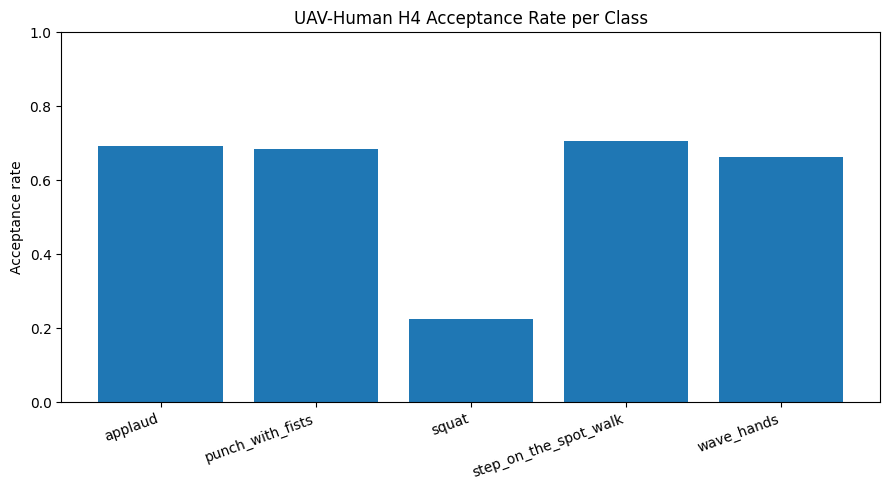

In [12]:
df_video = pd.DataFrame(video_rows)
df_sequence = pd.DataFrame(sequence_rows)

if df_video.empty or df_sequence.empty:
    raise RuntimeError('Tidak ada hasil yang cukup untuk diringkas.')

class_summary = (
    df_sequence
    .groupby('class')
    .agg(
        total_windows=('sequence_id', 'count'),
        accepted=('accepted', 'sum'),
        missing_ratio_mean=('missing_ratio', 'mean'),
        resampled_count=('menggunakan_resampling', 'sum'),
        unique_subjects=('subject_id', 'nunique'),
        unique_videos=('video_id', 'nunique'),
    )
    .reset_index()
)

class_summary['rejected'] = (
    class_summary['total_windows'] - class_summary['accepted']
)

class_summary['acceptance_rate'] = (
    class_summary['accepted'] / class_summary['total_windows']
)

display(class_summary)

plt.figure(figsize=(9, 5))
plt.bar(class_summary['class'], class_summary['acceptance_rate'])
plt.ylim(0, 1)
plt.ylabel('Acceptance rate')
plt.title('UAV-Human H4 Acceptance Rate per Class')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / 'acceptance_rate_per_class.png',
    dpi=160,
    bbox_inches='tight',
)
plt.show()


## 13. Simpan Output

In [13]:
X = (
    np.asarray(X_sequences, dtype=np.float32)
    if X_sequences
    else np.empty((0, SEQUENCE_LENGTH, FEATURE_DIM), dtype=np.float32)
)

y = np.asarray(y_labels, dtype=np.int64)
sequence_id_array = np.asarray(sequence_ids).astype(str)
source_video_array = np.asarray(source_video_ids).astype(str)
subject_id_array = np.asarray(subject_ids).astype(str)
setup_id_array = np.asarray(setup_ids).astype(str)
action_code_array = np.asarray(action_codes).astype(str)

assert X.shape[1:] == (SEQUENCE_LENGTH, FEATURE_DIM)
assert (
    len(X)
    == len(y)
    == len(sequence_id_array)
    == len(source_video_array)
    == len(subject_id_array)
    == len(setup_id_array)
    == len(action_code_array)
)

np.save(OUTPUT_DIR / 'X_sequences.npy', X)
np.save(OUTPUT_DIR / 'y_labels.npy', y)
np.save(OUTPUT_DIR / 'video_ids.npy', sequence_id_array)
np.save(OUTPUT_DIR / 'source_video_ids.npy', source_video_array)
np.save(OUTPUT_DIR / 'subject_ids.npy', subject_id_array)
np.save(OUTPUT_DIR / 'setup_ids.npy', setup_id_array)
np.save(OUTPUT_DIR / 'action_codes.npy', action_code_array)

with open(OUTPUT_DIR / 'class_mapping.json', 'w', encoding='utf-8') as file:
    json.dump(
        {index: name for index, name in enumerate(ACTIVITY_CLASSES)},
        file,
        indent=2,
        ensure_ascii=False,
    )

df_video.to_csv(OUTPUT_DIR / 'per_video_report.csv', index=False)
df_sequence.to_csv(OUTPUT_DIR / 'validation_report.csv', index=False)
class_summary.to_csv(OUTPUT_DIR / 'class_summary.csv', index=False)

report = {
    'dataset': 'UAV-Human RGBVideos 5-class subset',
    'classes': ACTIVITY_CLASSES,
    'class_folders': CLASS_FOLDERS,
    'pipeline': (
        'YOLOv8 detection -> target association -> smoothing/recovery -> '
        'crop+padding -> YOLO26 Pose -> COCO-17 -> sequence 90'
    ),
    'debug_mode': DEBUG_MODE,
    'total_videos_processed': int(len(df_video)),
    'total_sequences_accepted': int(len(X)),
    'shape': list(X.shape),
    'feature_dim': FEATURE_DIM,
    'split_recommendation': 'subject-wise split using subject_ids.npy',
}

with open(OUTPUT_DIR / 'validation_report.json', 'w', encoding='utf-8') as file:
    json.dump(report, file, indent=2, ensure_ascii=False)

print('X shape          :', X.shape)
print('y shape          :', y.shape)
print('Unique subjects  :', len(np.unique(subject_id_array)))
print('Unique videos    :', len(np.unique(source_video_array)))
print('Output           :', OUTPUT_DIR)


X shape          : (3634, 90, 51)
y shape          : (3634,)
Unique subjects  : 95
Unique videos    : 549
Output           : /kaggle/working/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90


## 14. Ringkasan Akhir

In [14]:
print('=' * 76)
print('UAV-HUMAN 5 CLASSES — H4 YOLO DETECTION + YOLO26 POSE')
print('=' * 76)
print('Classes             :', ACTIVITY_CLASSES)
print('Debug mode          :', DEBUG_MODE)
print('Video diproses      :', len(df_video))
print('Sequence diterima   :', len(X))
print('Output shape        :', X.shape)
print('Unique subjects     :', len(np.unique(subject_id_array)))
print('Output folder       :', OUTPUT_DIR)
print('=' * 76)

if DEBUG_MODE:
    print('Periksa overlay dan laporan. Jika aman, ubah DEBUG_MODE=False lalu Run All.')


UAV-HUMAN 5 CLASSES — H4 YOLO DETECTION + YOLO26 POSE
Classes             : ['applaud', 'wave_hands', 'punch_with_fists', 'squat', 'step_on_the_spot_walk']
Debug mode          : False
Video diproses      : 840
Sequence diterima   : 3634
Output shape        : (3634, 90, 51)
Unique subjects     : 95
Output folder       : /kaggle/working/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90
